In [8]:
import numpy as np
from scipy.spatial.distance import cdist
import torch
import pytest
from pwbarycentres import (
    asymmetric_sinkhorn_algorithm,
    generate_barycentredataprocessor,
)
import networkx as nx

torch.set_printoptions(precision=8)


In [9]:
n1, n2 = 11, 13
m1, m2 = 5, 7
L = 1.0
grid_type = "flat"
members = 3

In [10]:

if grid_type == "flat":
    X = torch.cartesian_prod(
        torch.linspace(0, L, n1), torch.linspace(0, L, n2)
    ).type(torch.DoubleTensor)
    Y = torch.cartesian_prod(
        torch.linspace(0, L, m1), torch.linspace(0, L, m2)
    ).type(torch.DoubleTensor)
    
elif grid_type == "tensor":
    X = torch.stack(
        torch.meshgrid(
            torch.linspace(0, L, n1), torch.linspace(0, L, n2), indexing="ij"
        ),
        dim=-1,
    ).type(torch.DoubleTensor)
elif grid_type == "tuple":
    X = (torch.linspace(0, L, n1), torch.linspace(0, L, n2))


In [11]:
data = []

for m in range(members):
    data.append([None, X])  # uniform density, grid will equal everywhere

In [12]:
# generate the barycentre dataprocessor class which will store all objects
# of interest. It will also create the correct graph, and given no density of graphs
# will create uniform densities on the grids
data_processor = generate_barycentredataprocessor(data, barycentre_grid=Y)

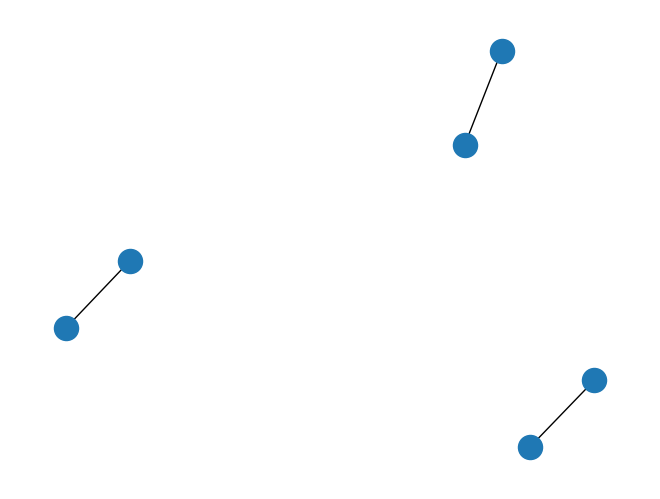

In [13]:
nx.draw(data_processor.graph)

In [14]:
# run asymmetric sinkhorn algorithm
data_processor, barycentre, potential_error_list, barycentre_error_list = (
    asymmetric_sinkhorn_algorithm(
        data_processor,
        epsilon=0.25, #1 / np.sqrt(n1 * n2),
        rho=1.0,
        aprox="balanced",
        max_iterates=50,
        tol=1e-5,
        epsilon_annealing=False,
        debiasing=False,
    )
)


RuntimeError: The size of tensor a (35) must match the size of tensor b (143) at non-singleton dimension 0

In [23]:
potential_error_list

[1.1459965773848082e+139,
 2.1012689567499556e+144,
 2.1012689567499556e+144,
 2.3251923933348795e+148,
 2.3251923933348795e+148,
 2.5368407624731323e+152,
 2.5368407624731323e+152,
 2.7676565832608367e+156,
 2.7676565832608367e+156,
 3.0194730390366966e+160,
 3.0194730390366966e+160,
 3.2942011254440133e+164,
 3.2942011254440133e+164,
 3.5939254679778554e+168,
 3.5939254679778554e+168,
 3.920920362031131e+172,
 3.920920362031131e+172,
 4.2776670307635386e+176,
 4.2776670307635386e+176,
 4.666872452518335e+180,
 4.666872452518335e+180,
 5.09148990125746e+184,
 5.09148990125746e+184,
 5.554741355876987e+188,
 5.554741355876987e+188,
 6.060141948444161e+192,
 6.060141948444161e+192,
 6.611526636867925e+196,
 6.611526636867925e+196,
 7.213079304394264e+200,
 7.213079304394264e+200,
 7.86936450673188e+204,
 7.86936450673188e+204,
 8.585362107704155e+208,
 8.585362107704155e+208,
 9.366505066241113e+212,
 9.366505066241113e+212,
 1.0218720661437671e+217,
 1.0218720661437671e+217,
 1.1148475

In [21]:
barycentre_error_list

[97.39765451340703,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355,
 97.39571938590355]

In [22]:
barycentre.sum()

tensor(1.00562301, dtype=torch.float64)

In [ ]:

print(barycentre, barycentre.sum().item())
assert np.abs(barycentre.sum().item() - 1.0) < 1e-12

for edges in data_processor.graph.edges():
    assert (
        np.abs(data_processor.data_dict[edges[0]]["density"].sum().item() - 1.0) < 1e-12
    ), (data_processor.data_dict[edges[0]]["density"].sum().item())
    assert (
        np.abs(data_processor.data_dict[edges[1]]["density"].sum().item() - 1.0) < 1e-12
    ), (data_processor.data_dict[edges[1]]["density"].sum().item())
